# 1. Lets Read data for Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
!pip install plotly

In [4]:
import plotly.express as px

In [5]:
 import os

In [6]:
os.listdir(r"C:\Users\rahul\Desktop\python\Uber\Datasets")

['other-American_B01362.csv',
 'other-Carmel_B00256.csv',
 'other-Dial7_B00887.csv',
 'other-Diplo_B01196.csv',
 'other-Federal_02216.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Highclass_B01717.csv',
 'other-Lyft_B02510.csv',
 'other-Prestige_B01338.csv',
 'other-Skyline_B00111.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-janjune-15.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv']

In [8]:
uber_15 = pd.read_csv(r"C:\Users\rahul\Desktop\python\Uber\Datasets\uber-raw-data-janjune-15.csv")

In [9]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90
...,...,...,...,...
14270474,B02765,2015-05-08 15:43:00,B02765,186
14270475,B02765,2015-05-08 15:43:00,B02765,263
14270476,B02765,2015-05-08 15:43:00,B02765,90
14270477,B02765,2015-05-08 15:44:00,B01899,45


In [10]:
type(uber_15)

pandas.DataFrame

# 2. Lets Perform Data Pre-Processing / Data Cleaning 

# Removing Duplicates

In [15]:
uber_15.shape

(14270479, 4)

In [10]:
uber_15.duplicated()

0           False
1           False
2           False
3           False
4           False
            ...  
14270474    False
14270475    False
14270476    False
14270477    False
14270478    False
Length: 14270479, dtype: bool

In [11]:
uber_15[uber_15.duplicated(keep= False)].sort_values(by = uber_15.columns.tolist())

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
6901294,B02512,2015-01-01 00:02:29,NaN,161
6901632,B02512,2015-01-01 00:02:29,NaN,161
6901313,B02512,2015-01-01 00:10:07,B02682,188
6901560,B02512,2015-01-01 00:10:07,B02682,188
6900994,B02512,2015-01-01 00:29:49,B02512,87
...,...,...,...,...
14085491,B02835,2015-06-30 21:44:00,B02835,231
14085554,B02835,2015-06-30 22:10:00,B02835,161
14085557,B02835,2015-06-30 22:10:00,B02835,161
14085615,B02835,2015-06-30 22:34:00,B02835,125


In [12]:
uber_15.drop_duplicates(inplace= True)

In [13]:
uber_15.duplicated().sum()

np.int64(0)

In [14]:
uber_15.shape

(13372254, 4)

# Missing Values

In [15]:
uber_15.isnull().sum()

Dispatching_base_num         0
Pickup_date                  0
Affiliated_base_num     160702
locationID                   0
dtype: int64

In [16]:
 uber_15.dtypes

Dispatching_base_num      str
Pickup_date               str
Affiliated_base_num       str
locationID              int64
dtype: object

In [17]:
#changing data types
uber_15["Pickup_date"]= pd.to_datetime(uber_15["Pickup_date"])

In [18]:
 uber_15.dtypes

Dispatching_base_num               str
Pickup_date             datetime64[us]
Affiliated_base_num                str
locationID                       int64
dtype: object

In [19]:
uber_15["Pickup_date"][0]

Timestamp('2015-05-17 09:47:00')

# 3. Which Month have max Uber pickups in new york city?

In [35]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90
...,...,...,...,...
14270474,B02765,2015-05-08 15:43:00,B02765,186
14270475,B02765,2015-05-08 15:43:00,B02765,263
14270476,B02765,2015-05-08 15:43:00,B02765,90
14270477,B02765,2015-05-08 15:44:00,B01899,45


In [20]:
uber_15['Month']=uber_15['Pickup_date'].dt.month_name()
uber_15['Weekday']=uber_15['Pickup_date'].dt.day_name()
uber_15['Day']=uber_15['Pickup_date'].dt.day
uber_15['Hour']=uber_15['Pickup_date'].dt.hour
uber_15['Minute']=uber_15['Pickup_date'].dt.minute

<Axes: xlabel='Month'>

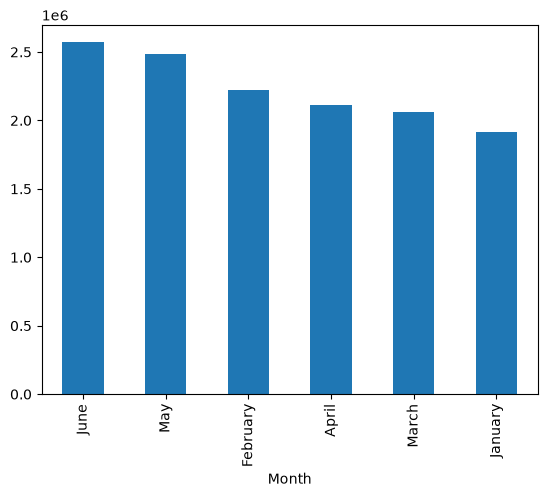

In [21]:
uber_15['Month'].value_counts().plot(kind= 'bar')

In [22]:
uber_15.head()

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,Month,Weekday,Day,Hour,Minute
0,B02617,2015-05-17 09:47:00,B02617,141,May,Sunday,17,9,47
1,B02617,2015-05-17 09:47:00,B02617,65,May,Sunday,17,9,47
2,B02617,2015-05-17 09:47:00,B02617,100,May,Sunday,17,9,47
3,B02617,2015-05-17 09:47:00,B02774,80,May,Sunday,17,9,47
4,B02617,2015-05-17 09:47:00,B02617,90,May,Sunday,17,9,47


In [23]:
pivot= pd.crosstab(index = uber_15['Month'], columns = uber_15['Weekday'])

In [24]:
pivot

Weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Month,,,,,,,
April,315002,238429,324545,273560,372522,250632,338015
February,373550,274948,368311,296130,335603,287260,286387
January,339285,190606,386049,230487,330319,196574,245650
June,371225,375312,399377,334434,357782,405500,328141
March,309631,269931,314785,313865,277026,320634,256767
May,430134,255501,464298,390391,337607,290004,316045


In [25]:
# Define the oders of months and weekday

Month_order=['January', 'February','March','April','May','June']

Weekday_order=['Monday', 'Tuesday', 'Wednesday','Thursday','Friday','Saturday','Sunday']

In [26]:
pivot_sorted=pivot.reindex(index =Month_order).reindex(columns = Weekday_order)

In [27]:
pivot_sorted

Weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Month,,,,,,,
January,190606,196574,245650,330319,339285,386049,230487
February,274948,287260,286387,335603,373550,368311,296130
March,269931,320634,256767,277026,309631,314785,313865
April,238429,250632,338015,372522,315002,324545,273560
May,255501,290004,316045,337607,430134,464298,390391
June,375312,405500,328141,357782,371225,399377,334434


In [28]:
Fig=px.bar(pivot_sorted,
      x=pivot_sorted.index,
      y=pivot_sorted.columns,
      barmode='group',
      title= 'Uber pickups by Month & Weekdays')

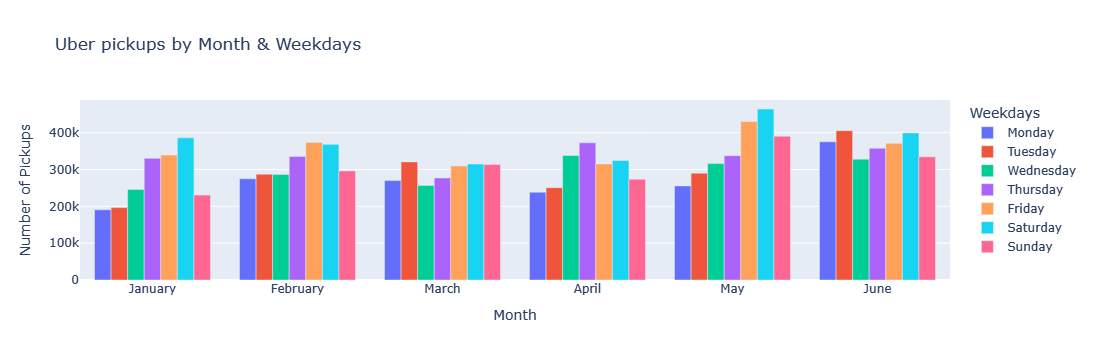

In [29]:
Fig.update_layout(
    xaxis_title ='Month',
    yaxis_title ='Number of Pickups',
    legend_title='Weekdays'
)

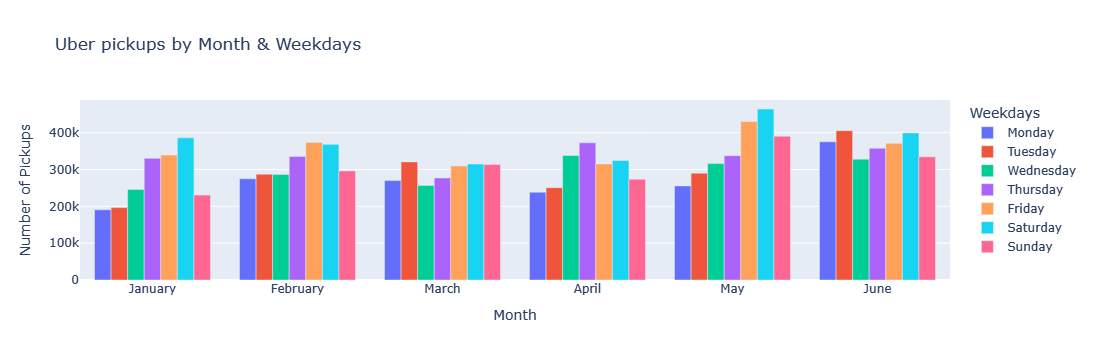

In [30]:
Fig

# 4. lets find out Hourly rush in New York City on all days

In [32]:
uber_15.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'Month', 'Weekday', 'Day', 'Hour', 'Minute'],
      dtype='str')

In [35]:
 hourly_rush= uber_15.groupby(['Weekday','Hour'], as_index= False).size()

In [36]:
hourly_rush

,Weekday,Hour,size
0,Friday,0,79879
1,Friday,1,44563
2,Friday,2,27252
3,Friday,3,19076
4,Friday,4,23049
...,...,...,...
163,Wednesday,19,131317
164,Wednesday,20,123490
165,Wednesday,21,120941
166,Wednesday,22,115208


In [37]:
hourly_rush.sort_values(['Weekday', 'Hour'])

,Weekday,Hour,size
0,Friday,0,79879
1,Friday,1,44563
2,Friday,2,27252
3,Friday,3,19076
4,Friday,4,23049
...,...,...,...
163,Wednesday,19,131317
164,Wednesday,20,123490
165,Wednesday,21,120941
166,Wednesday,22,115208


In [40]:
Weekday_order=['Monday', 'Tuesday', 'Wednesday','Thursday','Friday','Saturday','Sunday']

In [43]:
hourly_rush['Weekday']=pd.Categorical(hourly_rush['Weekday'],categories = Weekday_order,ordered=True)

In [45]:
hourly_rush= hourly_rush.sort_values(['Weekday', 'Hour'])
hourly_rush

,Weekday,Hour,size
24,Monday,0,47608
25,Monday,1,27093
26,Monday,2,16394
27,Monday,3,12461
28,Monday,4,18789
...,...,...,...
91,Sunday,19,99181
92,Sunday,20,91073
93,Sunday,21,88141
94,Sunday,22,90364


In [47]:
hourly_fig=px.line(hourly_rush,
    x="Hour",
    y="size",
    color="Weekday",
    markers= True,
       title="Hourly Uber Rush by days")

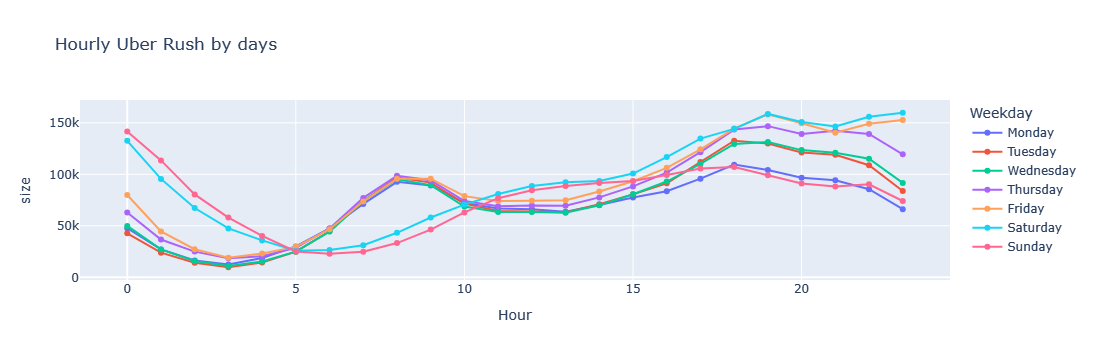

In [48]:
hourly_fig

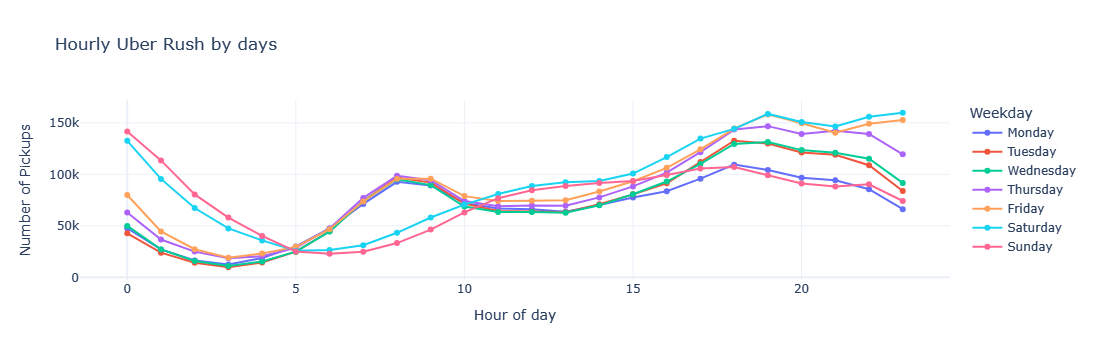

In [50]:
hourly_fig.update_layout(
    xaxis_title= "Hour of day",
    yaxis_title= "Number of Pickups",
    legend_title= "Weekday",
    template="plotly_white"
)

# 5 Pareto Analysis

In [51]:
uber_15.head(1)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,Month,Weekday,Day,Hour,Minute
0,B02617,2015-05-17 09:47:00,B02617,141,May,Sunday,17,9,47


In [58]:
base_counts= uber_15["Dispatching_base_num"].value_counts()

In [59]:
 base_counts

Dispatching_base_num
B02764    5377732
B02682    3151682
B02617    1973451
B02598    1468261
B02765    1122882
B02512     249808
B02835      26448
B02836       1990
Name: count, dtype: int64

In [60]:
base_counts.sum()

np.int64(13372254)

In [61]:
base_counts/base_counts.sum()

Dispatching_base_num
B02764    0.402156
B02682    0.235688
B02617    0.147578
B02598    0.109799
B02765    0.083971
B02512    0.018681
B02835    0.001978
B02836    0.000149
Name: count, dtype: float64

In [62]:
(base_counts/base_counts.sum()).cumsum()

Dispatching_base_num
B02764    0.402156
B02682    0.637844
B02617    0.785422
B02598    0.895221
B02765    0.979192
B02512    0.997873
B02835    0.999851
B02836    1.000000
Name: count, dtype: float64

In [64]:
base_df= base_counts.reset_index()

In [66]:
base_df.columns = ["Base","Trips"]

In [67]:
base_df

,Base,Trips
0,B02764,5377732
1,B02682,3151682
2,B02617,1973451
3,B02598,1468261
4,B02765,1122882
5,B02512,249808
6,B02835,26448
7,B02836,1990


In [70]:
base_df['Trip_percentage']=base_df['Trips']/base_df['Trips'].sum()

In [71]:
base_df

,Base,Trips,Trip_percentage
0,B02764,5377732,0.402156
1,B02682,3151682,0.235688
2,B02617,1973451,0.147578
3,B02598,1468261,0.109799
4,B02765,1122882,0.083971
5,B02512,249808,0.018681
6,B02835,26448,0.001978
7,B02836,1990,0.000149


In [72]:
base_df['cumulative_percentage']=base_df['Trip_percentage'].cumsum()

In [73]:
base_df

,Base,Trips,Trip_percentage,cumulative_percentage
0,B02764,5377732,0.402156,0.402156
1,B02682,3151682,0.235688,0.637844
2,B02617,1973451,0.147578,0.785422
3,B02598,1468261,0.109799,0.895221
4,B02765,1122882,0.083971,0.979192
5,B02512,249808,0.018681,0.997873
6,B02835,26448,0.001978,0.999851
7,B02836,1990,0.000149,1.000000


In [77]:
import plotly.graph_objs as go

In [90]:
    pareto=go.Figure([
        go.Bar(x = base_df['Base'], y = base_df['Trips'], name = 'Trips'
        ),
        go.Scatter(x = base_df['Base'], y = base_df['cumulative_percentage'],
                   yaxis= 'y2',
                   mode= 'lines+markers',
                   name='Cumalative %'
        )
    ])

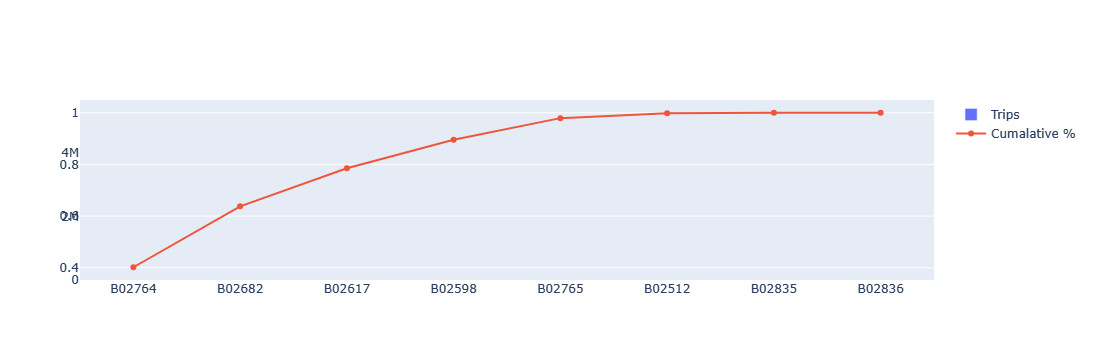

In [91]:
pareto

In [92]:
pareto=pareto.update_layout(
    yaxis2=dict(overlaying='y',side ='right',tickformat = '.0%', range=[0,1])
)

In [93]:
pareto=pareto.add_hline(y=0.8, yref ='y2', line_dash ='dash')

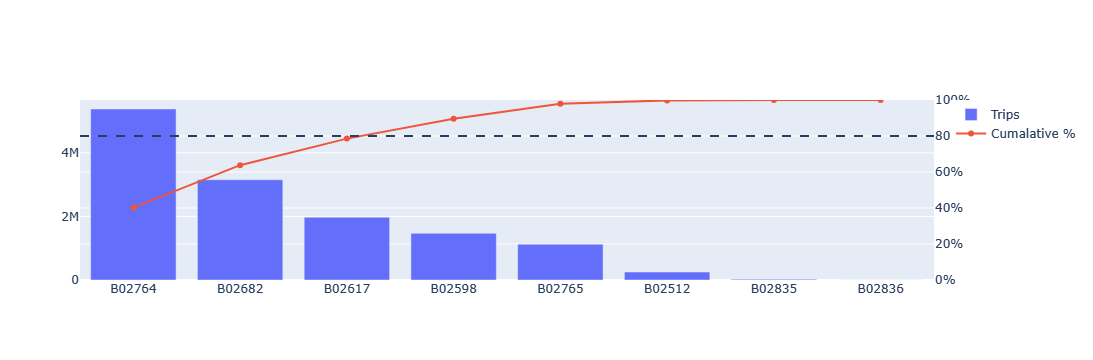

In [94]:
pareto

# 6 Airport demand analysis

In [101]:
sorted(uber_15['locationID'].unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.

In [102]:
airport_ids =[1,132,138]

In [106]:
airport_df=uber_15[uber_15['locationID'].isin(airport_ids)]

In [107]:
airport_map = {
    1: 'EWR',
    132:"JFK",
    138:'LGA',
}

In [110]:
airport_df['airport_name']=airport_df['locationID'].map(airport_map)

In [112]:
airport_df['airport_name'].value_counts()

airport_name
JFK    261476
LGA    238696
EWR       105
Name: count, dtype: int64

In [114]:
airport_df['hour']=airport_df['Pickup_date'].dt.hour

In [115]:
airport_df.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'Month', 'Weekday', 'Day', 'Hour', 'Minute',
       'airport_name', 'hour'],
      dtype='str')

In [119]:
airport_hourly=airport_df.groupby(by=['airport_name','hour']).size().reset_index(name='trips')
airport_hourly

,airport_name,hour,trips
0,EWR,1,1
1,EWR,4,3
2,EWR,5,4
3,EWR,6,13
4,EWR,7,6
...,...,...,...
61,LGA,19,17918
62,LGA,20,17908
63,LGA,21,19215
64,LGA,22,17184


In [121]:
area= px.area(airport_hourly,x='hour', y='trips', color='airport_name', title='Airport Demand Pressure')

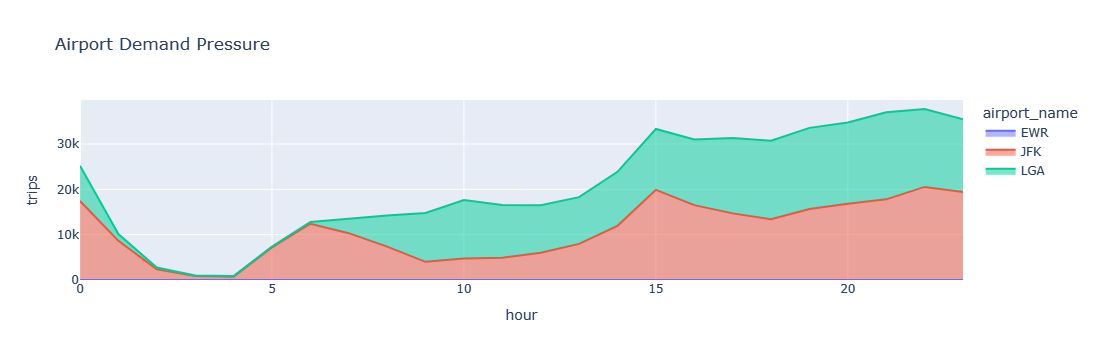

In [122]:
area

# 7 Collect entire data and Make it ready for the data analysis:

In [123]:
import os

In [124]:
file= os.listdir(r'C:\Users\rahul\Desktop\python\Uber\Datasets')

In [126]:
file

['other-American_B01362.csv',
 'other-Carmel_B00256.csv',
 'other-Dial7_B00887.csv',
 'other-Diplo_B01196.csv',
 'other-Federal_02216.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Highclass_B01717.csv',
 'other-Lyft_B02510.csv',
 'other-Prestige_B01338.csv',
 'other-Skyline_B00111.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-janjune-15.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv']

In [131]:
files_csv= [
   'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv'   
]

In [135]:

final= pd.DataFrame()
path = r'C:\Users\rahul\Desktop\python\Uber\Datasets'

for files in files_csv:
     current_df= pd.read_csv(path+'/'+files)
     final= pd.concat([current_df,final])

In [136]:
final.shape

(4534327, 4)

In [138]:
final.duplicated().sum()

np.int64(82581)

In [139]:
final.drop_duplicates(inplace=True)

In [140]:
final.shape

(4451746, 4)

In [141]:
final.head()

,Date/Time,Lat,Lon,Base
0,8/1/2014 0:03:00,40.7366,-73.9906,B02512
1,8/1/2014 0:09:00,40.7260,-73.9918,B02512
2,8/1/2014 0:12:00,40.7209,-74.0507,B02512
3,8/1/2014 0:12:00,40.7387,-73.9856,B02512
4,8/1/2014 0:12:00,40.7323,-74.0077,B02512


# 8 Data Loading : CSV vs JSON vs Database vs Bigdata

In [142]:
final.to_csv(r"C:\Users\rahul\Desktop\python\Uber\Preprocessed_data\uber_full_data.csv", index= False)

In [145]:
final.reset_index().to_json(r"C:\Users\rahul\Desktop\python\Uber\Preprocessed_data\uber.json")

In [146]:
!pip install sqlalchemy

In [147]:
from sqlalchemy import create_engine

In [148]:
engine=create_engine(r'sqlite:///C:\Users\rahul\Desktop\python\Uber\Preprocessed_data\uber.db.sqlite')

In [150]:
final.to_sql('Trips', con = engine, if_exists= 'append')

4451746

# 9 Hourly rush via Animated Spatial Analysis

In [151]:
final.dtypes

Date/Time        str
Lat          float64
Lon          float64
Base             str
dtype: object

In [153]:
final['Date/Time'] = pd.to_datetime(final['Date/Time'])

In [154]:
final.dtypes

Date/Time    datetime64[us]
Lat                 float64
Lon                 float64
Base                    str
dtype: object

In [156]:
final['hour']= final['Date/Time'].dt.hour

In [157]:
final['hour']

0          0
1          0
2          0
3          0
4          0
          ..
796116    23
796117    23
796118    23
796119    23
796120    23
Name: hour, Length: 4451746, dtype: int32

In [158]:
final.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base', 'hour'], dtype='str')

In [160]:
hourly_data =[]


for h in range(24):
    temp= final[final['hour'] == h][['Lat','Lon']]
    hourly_data.append(temp.values.tolist())

In [161]:
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [163]:
import folium
from folium.plugins import HeatMapWithTime

In [171]:
m= folium.Map(
    location = [40.7128 , -74.0060],
    zoom_start = 11,
    tiles = 'OpenStreetMap'
)

In [172]:
m

In [173]:
HeatMapWithTime(
    hourly_data, radius=9,
    auto_play = False,
    max_opacity= 0.8
).add_to(m)

In [174]:
m